# 202X SQM Data Plotter
**Basic functionality:**
<ul>
    <li> Read data using sqm_read2020. </li>
    <li> Clean data – float & lists create issues! </li>
    <li> Filter the data by lunar phase, cloud cover. </li>
</ul>

In [150]:
import numpy as np
import datetime
import pandas as pd
import sys
import matplotlib.pyplot as plt
plt.style.use('dark_background')
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import filter_dataframes
import numpy as np
from plot_scatter import plot_scatter
import sqm_plot202X
import matplotlib as mpl

## Data Processing

In [151]:
# Load the CSV
# Available data: FCZN, DSZN, HILT, SPZN
loc = 'SPZN'
year = '2021'
fdir = '/Users/jacksontobin/Local_Documents/NightTime_Research/FoCo Night Sky Team/SQM_DATA/SQM_COMPLETE'
# df_csv = f'{fdir}/{loc}_merged.csv'
df_csv = f'{fdir}/{loc}_combined.csv'
df = pd.read_csv(df_csv)
df = df.set_index(df['date'])
df.index = pd.to_datetime(df.index)

In [152]:
# Filter out data if the solar elevation is > -18 (astronomical twighlight cutoff)
df.loc[(df['sunalt_deg']) >= -18, 'mags'] = float('nan')

In [153]:
# Remove bogus data
cond = (df['mags'] < 0)
df['mags'] = df['mags'].mask(cond, np.nan)
df['date'] = pd.to_datetime(df['date'])

# Filter the date by years
df_yr = df[(df['date'] < datetime.datetime(year=int(year)+1,month=1,day=1)) & 
            (df['date'] > datetime.datetime(year=int(year),month=1,day=1))]

In [154]:
# Define Cloud-Cover by fraction:
def f(row):
    '''
    classifications from:
    https://www.eoas.ubc.ca/courses/atsc113/flying/met_concepts/01-met_concepts/01c-cloud_coverage/index.html
    '''
    r = row['cloudcover']
    if (r <= 10):
        val = 'CLR' # Clear
    elif (r > 10) & (r <= 30):
        val = 'FEW' # Few
    elif (r > 30) & (r <= 50):
        val = 'SCT' # Scattered
    elif (r > 50) & (r <= 90):
        val = 'BKN' # Broken
    elif (r > 90) & (r <= 100):
        val = 'OVC' # Overcast
    else:
        val = 'M' # Missing
    return val

df_yr['CC'] = df_yr.apply(f, axis=1)

/var/folders/hx/hcs55bp10f5fdvcmjf0rmf4r0000gn/T/ipykernel_66710/358446116.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_yr['CC'] = df_yr.apply(f, axis=1)


## Plot by Cloud-Cover, Lunar Phase

Data has high, mid, low, and total cloud-cover. First, we'll plot by total cloud-cover.

/Users/jacksontobin/Local_Documents/coding_shenanigans/SQM_new/sqm_plot202X.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe['month'] = dataframe.index.month


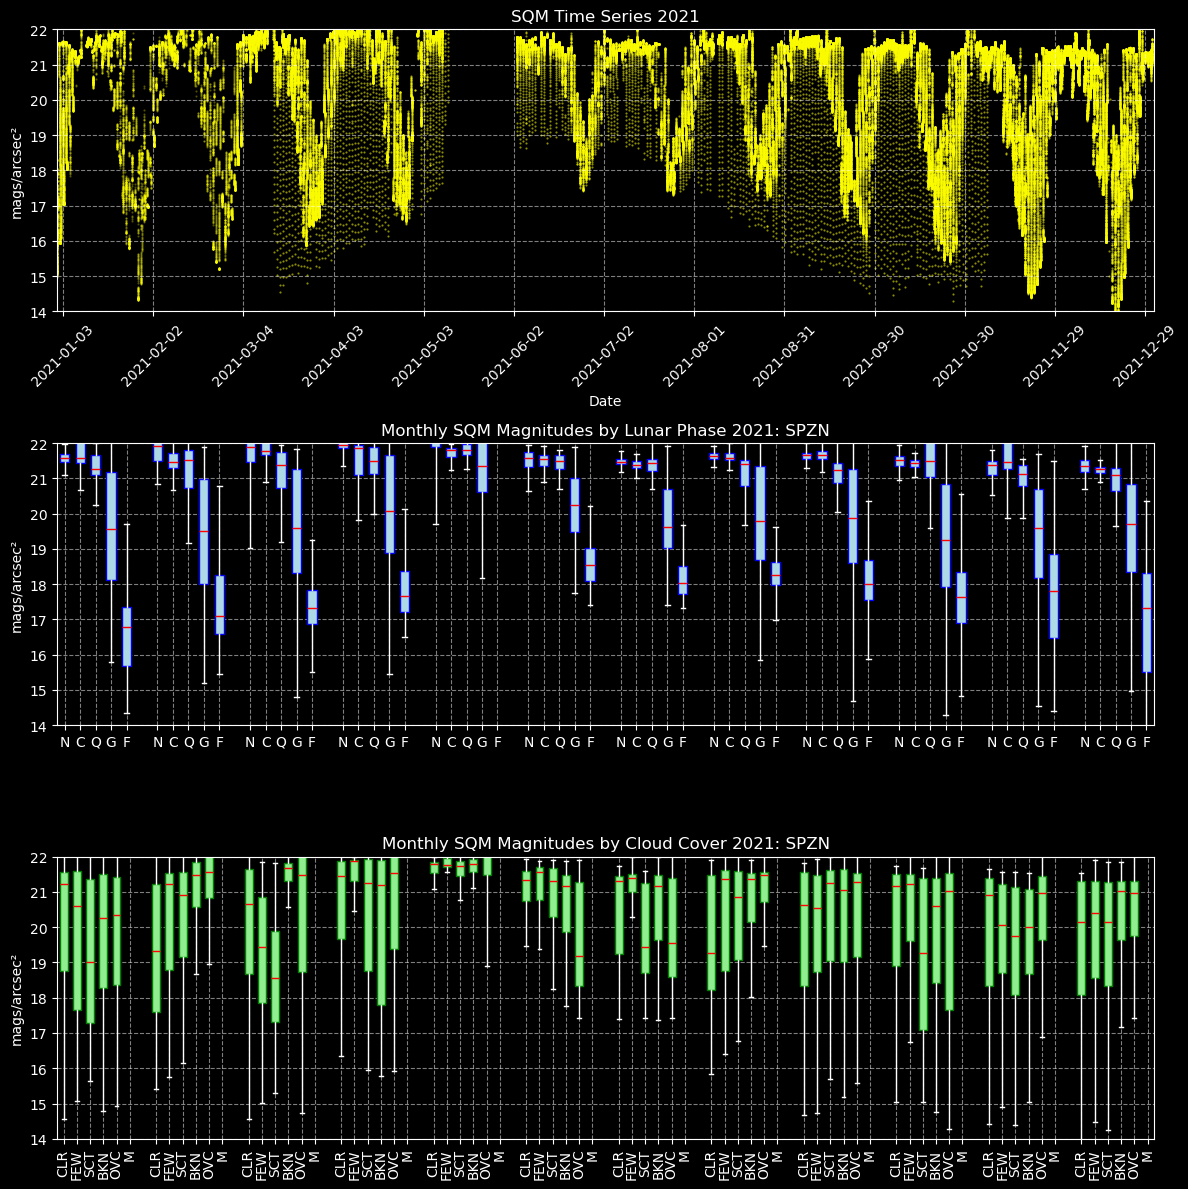

In [155]:
sqm_plot202X.sqm_plot202x(df_yr, title=loc, year=year, vmin=14, vmax=22)

## Type of Cloud-Cover
1st, analyze the isolated cloud effect.
- Remove "CLR" nights.
- Remove Lunar nights.

In [156]:
# Placeholder

### Regression: CC vs Brightness
Proxy analysis for the type of cloud-cover and its effect on brightness.

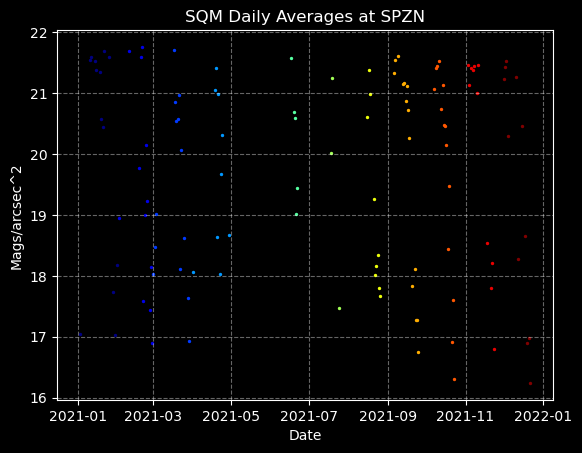

In [159]:
import sqm_regress202X

sqm_regress202X.regress_lunar_mags_average(df_yr, title=loc, year=year)

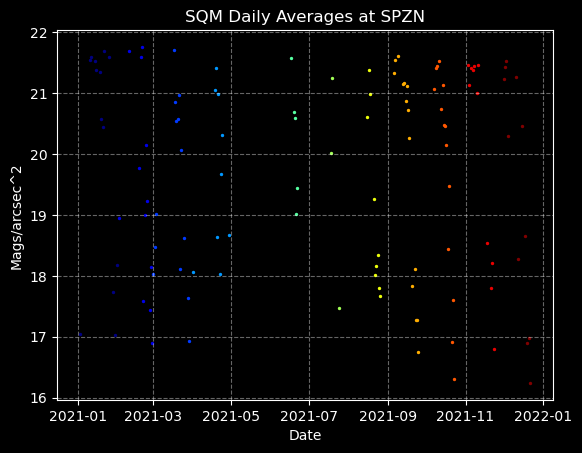

In [158]:


sqm_regress202X.regress_lunar_mags_average(df_yr, title=loc, year='2022')

# sqm_regress202X.regress_lunar_mags(df21, title=loc, year='2022')
# sqm_regress202X.regress_cc_mags(df21, title=loc, year='2022')